## import libraries

In [5]:
import warnings
warnings.filterwarnings('ignore')

import math

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, make_scorer

from functools import partial

from xgboost import XGBRegressor
import optuna
import plotly

import requests

import holidays
import datetime as dt

## define functions

In [106]:
##########################################################################
# calculate different metric scores and return them in a list
##########################################################################
def metric_results(y_train, y_train_pred, y_test, y_test_pred, ndigits=2, target_unit="target"):
    
    mean_load_test = y_test.mean()
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rel_mae_test  = mae_test / mean_load_test * 100
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    rel_rmse_test = rmse_test / mean_load_test * 100
    r2_test = r2_score(y_test, y_test_pred) * 100
   
    mean_load_train = y_train.mean()
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rel_mae_train  = mae_train / mean_load_train * 100
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rel_rmse_train = rmse_train / mean_load_train * 100
    r2_train = r2_score(y_train, y_train_pred) * 100   


    table = pd.DataFrame(
    [
        [">70%", "0", "0", "0%", "0%"],
        ["%", target_unit, target_unit, "%", "%"],
        [r2_train, rmse_train, mae_train, rel_rmse_train, rel_mae_train],
        [r2_test, rmse_test, mae_test, rel_rmse_test, rel_mae_test],
        [r2_train-r2_test, rmse_train-rmse_test, mae_train-mae_test, rel_rmse_train-rel_rmse_test, rel_mae_train-rel_mae_test]
    ],
    index=["optimal", "unit", "train", "test", "diff"],
    columns=["R²", "RMSE", "MAE", "relRMSE", "relMAE"]
    )

    num_rows = ["train", "test", "diff"]                    
    table.loc[num_rows] = (
        table.loc[num_rows].astype(float).round(ndigits)
    )

    return table

##########################################################################
# create range +- x % around the given value
##########################################################################
def pct_range(val, pct=0.10, lower=None, upper=None, integer=False):
    lo = val * (1 - pct)
    hi = val * (1 + pct)

    # observe strict boundaries (e.g. [0, 1])
    if lower is not None:
        lo = max(lo, lower)
    if upper is not None:
        hi = min(hi, upper)

    if integer:
        # if the value is an integer make a clean rounding
        lo = math.floor(lo)
        hi = math.ceil(hi)
        # make sure that there are at exactly 2 values to return
        if hi <= lo:
            hi = lo + 1

    return lo, hi


def get_season(month):
    if month in [12, 1, 2]:
        return 1 # , "winter"
    elif month in [3, 4, 5]:
        return 2 # , "spring"
    elif month in [6, 7, 8]:
        return 3 # , "summer"
    else:
        return 4 # , "autumn"
    
def encode_cyclic(df, col, max_val, offset=0):
    df[f"{col}_sin"] = np.sin(2 * np.pi * (df[col] + offset) / max_val)
    df[f"{col}_cos"] = np.cos(2 * np.pi * (df[col] + offset) / max_val)
    return df

def load_openmeteo_weather(lat=50.15, lon=6.33,
                           start="2023-01-01", end="2026-01-01",
                           tz="Europe/Berlin"):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "hourly": ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "shortwave_radiation",
            "precipitation",
            "cloud_cover"
        ]),
        "timezone": tz
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

    return df

def wet_bulb_temperature(T, RH):
    """
    T in °C, RH in %
    Stull formula (2011) – very accurate for practical use.
    """
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
          np.arctan(T + RH) - np.arctan(RH - 1.676331) +
          0.00391838 * (RH ** 1.5) * np.arctan(0.023101 * RH) -
          4.686035)

    return round(Tw, 2)


def heating_degree_day(temp_mean, base=18):
    return round(max(0, base - temp_mean), 2)


def cooling_degree_day(temp_mean, base=22):
    return round(max(0, temp_mean - base), 2)

def add_features(df):

    # we have 4 values for each hour -> value 2 hours -> shift by 4 values multiplied by 2 hours
    df["load_15min_ago"] = df["load_15min"].shift(1*1)
    df["load_30min_ago"] = df["load_15min"].shift(1*2)
    df["load_1h_ago"] = df["load_15min"].shift(1*4)
    df["load_2h_ago"] = df["load_15min"].shift(2*4)
    df["load_4h_ago"] = df["load_15min"].shift(4*4)
    df["load_6h_ago"] = df["load_15min"].shift(6*4)
    df["load_12h_ago"] = df["load_15min"].shift(12*4)
    df["load_24h_ago"] = df["load_15min"].shift(24*4)
    df["load_168h_ago"] = df["load_15min"].shift(168*4)

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_mean_1h"] = df["load_15min"].rolling(window=1*4).mean()
    df["rolling_mean_3h"] = df["load_15min"].rolling(window=3*4).mean()
    df["rolling_mean_4h"] = df["load_15min"].rolling(window=4*4).mean()
    df["rolling_mean_6h"] = df["load_15min"].rolling(window=6*4).mean()
    df["rolling_mean_12h"] = df["load_15min"].rolling(window=12*4).mean()
    df["rolling_mean_24h"] = df["load_15min"].rolling(window=24*4).mean()

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_std_3h"] = df["load_15min"].rolling(window=3*4).std()
    df["rolling_std_6h"] = df["load_15min"].rolling(window=6*4).std()
    df["rolling_std_12h"] = df["load_15min"].rolling(window=12*4).std()
    df.head(12)

    # Beispiel: 15min-Daten → Lags und rolling in Stunden & Tagen
    for col in ["temp","wet_bulb","radiation", "precip", "rel_humidity","wind","clouds"]:
        for steps in [1, 3, 6, 24, 48]:              # 1h, 3h, 6h, 1d, 2d
            df[f"{col}_lag{steps}h"] = df[col].shift(steps*4)
        for steps_2 in [3, 6, 12]:                    # 3h, 6h, 12h
            df[f"rolling_{col}_{steps_2}h"]  = df[col].rolling(steps_2*4, min_periods=1).mean()

    return df


##########################################################################
# define rough tuning ranges (best practice parameters that you think they are)
##########################################################################
def objective_rough_tune(trial, X_train, y_train, X_test, y_test):
    
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",  # using CPU
        "n_estimators": trial.suggest_int("n_estimators", 20, 2000),
        "max_depth": trial.suggest_int("max_depth", 1, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.8),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0)
        # "objective": "reg:squarederror",
        # "tree_method": "hist",  # using CPU
        # "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        # "max_depth": trial.suggest_int("max_depth", 3, 8),
        # "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        # "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        # "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
        # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        # "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        # "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 8.0)
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    return rmse

##########################################################################
# define fine tuning ranges around best parameters found before
##########################################################################
def objective_fine_tune(trial, fine_tune_range, best_params, X_train, y_train, X_test, y_test):

    # create ranges
    n_estimators_low, n_estimators_high = pct_range(
        best_params["n_estimators"], pct=fine_tune_range, lower=20, upper=50000, integer=True
    )

    max_depth_low, max_depth_high = pct_range(
        best_params["max_depth"], pct=fine_tune_range, lower=1, upper=32, integer=True
    )

    lr_low, lr_high = pct_range(
        best_params["learning_rate"], pct=fine_tune_range, lower=1e-4, upper=1.0, integer=False
    )

    subsample_low, subsample_high = pct_range(
        best_params["subsample"], pct=fine_tune_range, lower=0.1, upper=1.0, integer=False
    )

    colsample_low, colsample_high = pct_range(
        best_params["colsample_bytree"], pct=fine_tune_range, lower=0.1, upper=1.0, integer=False
    )

    mcw_low, mcw_high = pct_range(
        best_params.get("min_child_weight", 1), pct=fine_tune_range, lower=1, upper=256, integer=True
    )

    gamma_low, gamma_high = pct_range(
        best_params.get("gamma", 0.0), pct=fine_tune_range, lower=0.0, upper=10.0, integer=False
    )

    reg_alpha_low, reg_alpha_high = pct_range(
        best_params.get("reg_alpha", 0.0), pct=fine_tune_range, lower=0.0, upper=10.0, integer=False
    )

    reg_lambda_low, reg_lambda_high = pct_range(
        best_params.get("reg_lambda", 1.0), pct=fine_tune_range, lower=1e-6, upper=100.0, integer=False
    )

    # --- Optuna-Samples ---
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",  # use CPU
        "n_estimators": trial.suggest_int("n_estimators", n_estimators_low, n_estimators_high),
        "max_depth": trial.suggest_int("max_depth", max_depth_low, max_depth_high),
        "learning_rate": trial.suggest_float("learning_rate", lr_low, lr_high, log=True),
        "subsample": trial.suggest_float("subsample", subsample_low, subsample_high),
        "colsample_bytree": trial.suggest_float("colsample_bytree", colsample_low, colsample_high),
        "min_child_weight": trial.suggest_int("min_child_weight", mcw_low, mcw_high),
        "gamma": trial.suggest_float("gamma", gamma_low, gamma_high),
        "reg_alpha": trial.suggest_float("reg_alpha", reg_alpha_low, reg_alpha_high, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", reg_lambda_low, reg_lambda_high, log=True),
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_eval_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_eval_pred))

    return rmse

##########################################################################
# load dataset (only timestamp and load as str), add weather data (from API) and add/calculate some features
##########################################################################
def load_data_and_weather(path, lat, lon, tz):
    ##################################################################
    # load raw load data
    ##################################################################
    df_future = pd.read_csv(path, header=None, names=["date_time","load_15min"] )
    df_future = df_future[2:]                       # delete first two rows (old headers)
    df_future["date_time"] = pd.to_datetime(df_future["date_time"])
    df_future = df_future.set_index("date_time")    # set column date_time as index
    df_future = df_future.sort_index()              # sort by index (timestamp)

    ##################################################################
    # load weather data
    ##################################################################
    start = df_future.index.min().date().isoformat()   # get the oldest date in this format -> "YYYY-MM-DD"
    end = df_future.index.max().date().isoformat()     # get the youngest date in this format -> "YYYY-MM-DD"

    print(f"📅 - start date: {start}, end date: {end}")
    df_weather_hourly = load_openmeteo_weather(lat=lat,        # latitude for 54597 Pronsfeld, Germany
                                            lon=lon,           # longitude for 54597 Pronsfeld, Germany
                                            start=start,        # define start date based on oldest date in load dataset -> or "YYYY-MM-DD"
                                            end=end,            # define end date based on youngest date in load dataset -> or "YYYY-MM-DD"
                                            tz=tz)           # "Europe/Berlin" -> UTC better for forecasting

    # resample to 15-min resolution -> electrical load has the same resolution
    df_weather_15min = df_weather_hourly.resample("15min").interpolate()

    # renaming columns
    df_weather_15min = df_weather_15min.rename(columns={
        "temperature_2m": "temp",
        "relative_humidity_2m": "rel_humidity",
        "wind_speed_10m": "wind",
        "shortwave_radiation": "radiation",
        "precipitation": "precip",
        "cloud_cover": "clouds"
    })
    ##################################################################
    # join both DataFrames
    ##################################################################
    df = df_future.join(df_weather_15min, how="left")

    ##################################################################
    #convert load_15min from string to int and MW to kW
    ##################################################################
    col = "load_15min"          # set column name
 
    # calculate new column
    df[col] = (
        pd.to_numeric(
            df[col]
                .astype(str)                              # make sure that all values are strings
                .str.replace(",", ".", regex=False)       # if it exists, replace decimal separator ("," with ".")
                .str.extract(r"([-+]?\d*\.?\d+)")[0],     # extract only the first number out of the string
            errors="coerce"
        )
        .mul(1000)          # change unit (MW to kW)
        .round()            # avoid rounding error by multiplying in the previous row
        .astype("Int64")    # int64 because i don't want an error for the NaN values
    )

    ##################################################################
    # calculate wet bulb temperature
    df["wet_bulb"] = wet_bulb_temperature(
                                    df["temp"],
                                    df["rel_humidity"])
    
    ##################################################################
    # calculate hdd and cdd
    ##################################################################
    df["date"] = df.index.date          # create date column
    daily_mean = df.groupby("date")["temp"].mean()    # group by date to calculate the mean temperature for each day

    # calculate daily hdd and cdd
    df_hdd = daily_mean.apply(lambda T: heating_degree_day(T, base=15)) # base -> existing buildings = 15°C; low-energy houses = 12°C; passive houses = 10°C
    df_cdd = daily_mean.apply(lambda T: cooling_degree_day(T, base=22))

    df_degree_days = pd.DataFrame({
        "date": df_hdd.index,
        "hdd_daily": df_hdd.values,
        "cdd_daily": df_cdd.values
    }).set_index("date")

    df["date"] = df.index.date

    # Date as Key
    df = df.join(
        df_degree_days,
        on="date"
    )

    # calculate quarterly hdd and cdd
    df["hdd_quarterly"] = df["temp"].apply(lambda T: heating_degree_day(T, base=15))
    df["cdd_quarterly"] = df["temp"].apply(lambda T: cooling_degree_day(T, base=22))

    ##################################################################
    # add features
    ##################################################################
    # we have 4 values for each hour -> value 2 hours -> shift by 4 values multiplied by 2 hours
    df["load_15min_ago"] = df["load_15min"].shift(1*1)
    df["load_30min_ago"] = df["load_15min"].shift(1*2)
    df["load_1h_ago"] = df["load_15min"].shift(1*4)
    df["load_2h_ago"] = df["load_15min"].shift(2*4)
    df["load_4h_ago"] = df["load_15min"].shift(4*4)
    df["load_6h_ago"] = df["load_15min"].shift(6*4)
    df["load_12h_ago"] = df["load_15min"].shift(12*4)
    df["load_24h_ago"] = df["load_15min"].shift(24*4)

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_mean_1h"] = df["load_15min"].rolling(window=1*4).mean()
    df["rolling_mean_4h"] = df["load_15min"].rolling(window=4*4).mean()   
    df["rolling_mean_24h"] = df["load_15min"].rolling(window=24*4).mean()

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_std_3h"] = df["load_15min"].rolling(window=3*4).std()
    df["rolling_std_6h"] = df["load_15min"].rolling(window=6*4).std()
    df["rolling_std_12h"] = df["load_15min"].rolling(window=12*4).std()

    # create lags temperature
    for steps in [1, 3, 24]:              # 1h, 3h, 6h, 1d, 2d
        df[f"temp_lag{steps}h"] = df["temp"].shift(steps*4)


    # hour of the day (0 - 23)
    df["hour"] = df.index.hour
    # minute of the hour (0 - 59)
    df["minute"] = df.index.minute
    # time of day in minutes (0 - 1439)
    df["time"] = df["hour"] * 60 + df["minute"]
    # month of the year (1 - 12)
    df["month"] = df.index.month
    # season (1=winter; ... ; 4=autumn)
    df["season"] = df.index.month.map(get_season)
    # hour of the day (0 - 23) -> transform to sine and cosine
    df = encode_cyclic(df,"hour", 24)
    # minute of the hours (0 - 59) -> transform to sine and cosine
    df = encode_cyclic(df,"minute", 60)
    # time of day in minutes (0 - 1439) -> transform to sine and cosine
    df = encode_cyclic(df,"time", 24*60)
    # month (1 - 12) -> transform to sine and cosine
    df = encode_cyclic(df,"month", 24*60, offset=-1)
    # season (1 - 4) -> transform to sine and cosine
    df = encode_cyclic(df,"season", 4, offset=-1)

    # weekday (monday=0 ... sunday=6)
    df["weekday"] = df.index.dayofweek
    dummies = pd.get_dummies(df["weekday"], prefix="weekday")   # I don't want to drop the old column "weekend"
    df = pd.concat([df, dummies], axis=1)
    df = encode_cyclic(df, "weekday", 7)

    # weekend
    df["weekend"] = 0
    df.loc[(df["weekday"] >= 5), "weekend"] = 1
    weekend_days = df["weekend"][df["weekend"] == 1].count()
    sat_sun_days = df["weekday"][(df["weekday"] >= 5)].count()

    # shifts and shift change
    df["early_shift"] = 0
    df["late_shift"] = 0
    df["night_shift"] = 0
    df.loc[(df.index.hour >= 6) & (df.index.hour < 14),"early_shift"] = 1
    df.loc[(df.index.hour >= 14) & (df.index.hour < 22),"late_shift"] = 1
    df.loc[(df.index.hour >= 22) | (df.index.hour < 6),"night_shift"] = 1
    time_sc_el = 14     # time when shift changes from early shift to late shift
    time_sc_ln = 22     # time when shift changes from late shift to night shift
    time_sc_ln = 6      # time when shift changes from night shift to early shift
    time_sc_diff = 1    # 1h -> do not change!!!

    shiftchange_el = (df.index.hour >= time_sc_el - time_sc_diff) & (df.index.hour < time_sc_el + time_sc_diff)
    shiftchange_ln = (df.index.hour >= time_sc_ln - time_sc_diff) & (df.index.hour < time_sc_ln + time_sc_diff)
    shiftchange_ne = (df.index.hour >= time_sc_ln - time_sc_diff) & (df.index.hour < time_sc_ln + time_sc_diff)

    df["shiftchange_el"] = 0
    df["shiftchange_ln"] = 0
    df["shiftchange_ne"] = 0
    df.loc[shiftchange_el,"shiftchange_el"] = 1
    df.loc[shiftchange_ln,"shiftchange_ln"] = 1
    df.loc[shiftchange_ne,"shiftchange_ne"] = 1


    # german holidays for Rhineland-Palatinate
    var_holidays = holidays.Germany(years=df.index.year.unique(), prov="RP")

    # creat column: 1 = holiday, 0 = normal day
    df["date"] = df.index.date    # extract date to compare with the date of the holidays list
    df["holiday"] = df["date"].isin(var_holidays).astype(int)

    # creat column: 1 = bridging day, 0 = not a bridging day
    holiday_dates = list(var_holidays.keys())  # datetime.date Objekte

    # bridging days
    bridge_days = set()

    for h in holiday_dates:
        # day before the holiday (only if holiday is on tuesday -> the day before is monday)
        prev_day = h - dt.timedelta(days=1)     # subtract one day from the holiday date
        if prev_day.weekday() == 0:  # 0 = monday
            bridge_days.add(prev_day)

        # day after the holiday (only if holiday is on thursday -> the day after is friday)
        next_day = h + dt.timedelta(days=1)     # add one day to the holiday date
        if next_day.weekday() == 4:  # 4 = friday
            bridge_days.add(next_day)

    bridge_days = sorted(list(bridge_days))

    df["bridging_day"] = (df["date"].isin(bridge_days)).astype(int)

    ##################################################################
    # order the columns new and delete columns that are nit necessary
    ##################################################################
    # keep_cols = ['load_15min', 'load_15min_ago', 'load_30min_ago', 'load_1h_ago', 'load_2h_ago', 'load_4h_ago', 'load_6h_ago', 'load_12h_ago', 'load_24h_ago', 'rolling_mean_1h', 'rolling_mean_4h', 'rolling_mean_24h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'weekend', 'early_shift', 'late_shift', 'night_shift', 'shiftchange_el', 'shiftchange_ln', 'shiftchange_ne', 'holiday', 'bridging_day', 'temp', 'temp_lag1h', 'temp_lag3h', 'temp_lag24h', 'rel_humidity', 'wind', 'radiation', 'precip']
    # df = df[keep_cols]

    ##################################################################
    # delete outliers in the load
    ##################################################################
    df.loc[df["load_15min"] > 15000, "load_15min"] = pd.NA

    ##################################################################
    # interpolate missing values
    ##################################################################
    df = (
        df
            .interpolate(method="time", limit_direction="both")   # fill in both directions to fill the beginning and end to
        )

    df["load_15min"] = (
        df["load_15min"]
            .round()
            .astype("Int64")              # change float + NaN → Int64 + <NA>
    )

    ##################################################################
    # checking if there are missing values
    ##################################################################
    nan_counts = df.isna().sum()
    nan_columns = nan_counts[nan_counts > 0]

    if not nan_columns.empty:
        print("❌ - Error: There are columns with missing values:")
        print(nan_columns)
    else:
        print("✅ - Success: There are no missing values in the Data!")

    display(df.head())

    return df

##########################################################################
# function to add rolling and lag features
##########################################################################
def add_features(df):

    # we have 4 values for each hour -> value 2 hours -> shift by 4 values multiplied by 2 hours
    df["load_15min_ago"] = df["load_15min"].shift(1*1)
    df["load_30min_ago"] = df["load_15min"].shift(1*2)
    df["load_1h_ago"] = df["load_15min"].shift(1*4)
    df["load_2h_ago"] = df["load_15min"].shift(2*4)
    df["load_4h_ago"] = df["load_15min"].shift(4*4)
    df["load_6h_ago"] = df["load_15min"].shift(6*4)
    df["load_12h_ago"] = df["load_15min"].shift(12*4)
    df["load_24h_ago"] = df["load_15min"].shift(24*4)
    df["load_168h_ago"] = df["load_15min"].shift(168*4)

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_mean_1h"] = df["load_15min"].rolling(window=1*4).mean()
    df["rolling_mean_3h"] = df["load_15min"].rolling(window=3*4).mean()
    df["rolling_mean_4h"] = df["load_15min"].rolling(window=4*4).mean()
    df["rolling_mean_6h"] = df["load_15min"].rolling(window=6*4).mean()
    df["rolling_mean_12h"] = df["load_15min"].rolling(window=12*4).mean()
    df["rolling_mean_24h"] = df["load_15min"].rolling(window=24*4).mean()

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_std_3h"] = df["load_15min"].rolling(window=3*4).std()
    df["rolling_std_6h"] = df["load_15min"].rolling(window=6*4).std()
    df["rolling_std_12h"] = df["load_15min"].rolling(window=12*4).std()
    df.head(12)

    # Beispiel: 15min-Daten → Lags und rolling in Stunden & Tagen
    for col in ["temp","wet_bulb","radiation", "precip", "rel_humidity","wind","clouds"]:
        for steps in [1, 3, 6, 24, 48]:              # 1h, 3h, 6h, 1d, 2d
            df[f"{col}_lag{steps}h"] = df[col].shift(steps*4)
        for steps_2 in [3, 6, 12]:                    # 3h, 6h, 12h
            df[f"rolling_{col}_{steps_2}h"]  = df[col].rolling(steps_2*4, min_periods=1).mean()

    return df

##########################################################################
# create a forecast for the next 24h
##########################################################################
def forecast_24h(model, df_last, feature_cols, horizon=96):

    df_fc = df_last.copy()
    preds = []

    for _ in range(horizon):

        #  actual feature row (t)
        x_t = df_fc[feature_cols].iloc[[-1]]

        # prediction for t+15
        y_pred = model.predict(x_t).item()

        # calculate new timstamp
        next_ts = df_fc.index[-1] + pd.Timedelta("15min")

        # create new row with predicted load_15min
        new_row = df_fc.iloc[[-1]].copy()
        new_row.index = [next_ts]
        new_row["load_15min"] = y_pred

        # concat new row
        df_fc = pd.concat([df_fc, new_row])

        # calculate features for the new rows
        df_fc = add_features(df_fc)   

        preds.append(y_pred)

    # build Forecast-Series 
    idx = pd.date_range(
        start=df_last.index[-1] + pd.Timedelta("15min"),
        periods=horizon,
        freq="15min"
    )

    return pd.Series(preds, index=idx, name="forecast")



## 1. - choose which columns to keep

In [103]:
keep_columns = [
    "load_15min",
    "load_15min_ago", "load_30min_ago",
    "load_1h_ago", "load_2h_ago", "load_4h_ago", "load_6h_ago", 
    "load_12h_ago", "load_24h_ago",# "load_168h_ago", 
    # "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
    "rolling_mean_1h", "rolling_mean_4h", "rolling_mean_24h",
    # "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",

    # "hour",   
    "hour_sin", "hour_cos", 
    # "minute",
    # "minute_sin", "minute_cos",
    # "time_sin", "time_cos",
    # "month",
    "month_sin", "month_cos",
    # "season",
    # "season_sin", "season_cos",   # -> already in weekday_sin/cos und month_sin/cos
    # "weekday", 
    # "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
    "weekday_sin", "weekday_cos", 
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
    # weather
    "temp",# "rolling_temp_3h",# "rolling_temp_6h", "rolling_temp_12h",
    "temp_lag1h", "temp_lag3h", "temp_lag24h",# "temp_lag6h",# "temp_lag48h",
    
    "rel_humidity",# "rolling_rel_humidity_3h",# "rolling_rel_humidity_6h", "rolling_rel_humidity_12h",
    # "rel_humidity_lag1h",# "rel_humidity_lag3h", "rel_humidity_lag6h", "rel_humidity_lag24h",# "rel_humidity_lag48h",
    
    "wind",# "rolling_wind_3h",# "rolling_wind_6h", "rolling_wind_12h",
    # "wind_lag1h",# "wind_lag3h", "wind_lag6h", "wind_lag24h",# "wind_lag48h",
    
    "radiation",# "rolling_radiation_3h",# "rolling_radiation_6h", "rolling_radiation_12h",
    # "radiation_lag1h",# "radiation_lag3h", "radiation_lag6h", "radiation_lag24h",# "radiation_lag48h",

    "precip",# "rolling_precip_3h",# "rolling_precip_6h", "rolling_precip_12h",
    # "precip_lag1h",# "precip_lag3h", "precip_lag6h", "precip_lag24h",# "precip_lag48h",

    # "clouds", "rolling_clouds_3h",# "rolling_clouds_6h", "rolling_clouds_12h",
    # "clouds_lag1h",# "clouds_lag3h", "clouds_lag6h", "clouds_lag24h",# "clouds_lag48h",

    # "hdd_daily",
    # "hdd_quarterly",

    # "cdd_daily",
    # "cdd_quarterly",

    # "wet_bulb",# "rolling_wet_bulb_3h",# "rolling_wet_bulb_6h", "rolling_wet_bulb_12h",
    # "wet_bulb_lag1h",# "wet_bulb_lag3h", "wet_bulb_lag6h", "wet_bulb_lag24h",# "wet_bulb_lag48h",
]

keep_columns_no_weather = [
    "load_15min",
    "load_15min_ago", "load_30min_ago",
    "load_1h_ago", "load_2h_ago", "load_4h_ago", "load_6h_ago",
    "load_12h_ago", "load_24h_ago",
    "rolling_mean_1h", "rolling_mean_4h", "rolling_mean_24h",
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "weekday_sin", "weekday_cos",
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
]

keep_columns_more_weather = [
    "load_15min",
    "load_15min_ago", "load_30min_ago",
    "load_1h_ago", "load_2h_ago", "load_4h_ago", "load_6h_ago", 
    "load_12h_ago", "load_24h_ago",# "load_168h_ago", 
    # "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
    "rolling_mean_1h", "rolling_mean_4h", "rolling_mean_24h",
    # "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",

    # "hour",   
    "hour_sin", "hour_cos", 
    # "minute",
    # "minute_sin", "minute_cos",
    # "time_sin", "time_cos",
    # "month",
    "month_sin", "month_cos",
    # "season",
    # "season_sin", "season_cos",   # -> already in weekday_sin/cos und month_sin/cos
    # "weekday", 
    # "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
    "weekday_sin", "weekday_cos", 
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
    # weather
    "temp",# "rolling_temp_3h",# "rolling_temp_6h", "rolling_temp_12h",
    "temp_lag1h", "temp_lag3h", "temp_lag24h",# "temp_lag6h",# "temp_lag48h",
    
    "rel_humidity",# "rolling_rel_humidity_3h",# "rolling_rel_humidity_6h", "rolling_rel_humidity_12h",
    "rel_humidity_lag1h",# "rel_humidity_lag3h", "rel_humidity_lag6h", "rel_humidity_lag24h",# "rel_humidity_lag48h",
    
    "wind",# "rolling_wind_3h",# "rolling_wind_6h", "rolling_wind_12h",
    "wind_lag1h",# "wind_lag3h", "wind_lag6h", "wind_lag24h",# "wind_lag48h",
    
    "radiation",# "rolling_radiation_3h",# "rolling_radiation_6h", "rolling_radiation_12h",
    "radiation_lag1h",# "radiation_lag3h", "radiation_lag6h", "radiation_lag24h",# "radiation_lag48h",

    "precip",# "rolling_precip_3h",# "rolling_precip_6h", "rolling_precip_12h",
    "precip_lag1h",# "precip_lag3h", "precip_lag6h", "precip_lag24h",# "precip_lag48h",

    "clouds",# "rolling_clouds_3h",# "rolling_clouds_6h", "rolling_clouds_12h",
    "clouds_lag1h",# "clouds_lag3h", "clouds_lag6h", "clouds_lag24h",# "clouds_lag48h",

    # "hdd_daily",
    "hdd_quarterly",

    # "cdd_daily",
    "cdd_quarterly",

    "wet_bulb",# "rolling_wet_bulb_3h",# "rolling_wet_bulb_6h", "rolling_wet_bulb_12h",
    "wet_bulb_lag1h",# "wet_bulb_lag3h", "wet_bulb_lag6h", "wet_bulb_lag24h",# "wet_bulb_lag48h",
]

keep_columns_test = [
    "load_15min",
    # "load_15min_ago", "load_30min_ago",
    # "load_1h_ago", "load_2h_ago", "load_4h_ago", "load_6h_ago", 
    # "load_12h_ago", "load_24h_ago",# "load_168h_ago", 
    # # "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
    # "rolling_mean_1h", "rolling_mean_4h", "rolling_mean_24h",
    # # "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",

    # "hour",   
    "hour_sin", "hour_cos", 
    # "minute",
    # "minute_sin", "minute_cos",
    # "time_sin", "time_cos",
    # "month",
    "month_sin", "month_cos",
    # "season",
    # "season_sin", "season_cos",   # -> already in weekday_sin/cos und month_sin/cos
    # "weekday", 
    # "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
    "weekday_sin", "weekday_cos", 
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
    # weather
    # "temp",# "rolling_temp_3h",# "rolling_temp_6h", "rolling_temp_12h",
    # "temp_lag1h", "temp_lag24h", "temp_lag3h", "temp_lag6h",# "temp_lag48h",
    
    # "rel_humidity",# "rolling_rel_humidity_3h",# "rolling_rel_humidity_6h", "rolling_rel_humidity_12h",
    # "rel_humidity_lag1h",# "rel_humidity_lag3h", "rel_humidity_lag6h", "rel_humidity_lag24h",# "rel_humidity_lag48h",
    
    # "wind",# "rolling_wind_3h",# "rolling_wind_6h", "rolling_wind_12h",
    # "wind_lag1h",# "wind_lag3h", "wind_lag6h", "wind_lag24h",# "wind_lag48h",
    
    # "radiation",# "rolling_radiation_3h",# "rolling_radiation_6h", "rolling_radiation_12h",
    "radiation_lag1h",# "radiation_lag3h", "radiation_lag6h", "radiation_lag24h",# "radiation_lag48h",

    # "precip",# "rolling_precip_3h",# "rolling_precip_6h", "rolling_precip_12h",
    # "precip_lag1h",# "precip_lag3h", "precip_lag6h", "precip_lag24h",# "precip_lag48h",

    # "clouds",# "rolling_clouds_3h",# "rolling_clouds_6h", "rolling_clouds_12h",
    # "clouds_lag1h",# "clouds_lag3h", "clouds_lag6h", "clouds_lag24h",# "clouds_lag48h",

    # "hdd_daily",
    "hdd_quarterly",

    # "cdd_daily",
    "cdd_quarterly",

    "wet_bulb",# "rolling_wet_bulb_3h",# "rolling_wet_bulb_6h", "rolling_wet_bulb_12h",
    # "wet_bulb_lag1h",# "wet_bulb_lag3h", "wet_bulb_lag6h", "wet_bulb_lag24h",# "wet_bulb_lag48h",
]

# 2. - train XGBoost model (automatically rough and fine tuned with optuna) | includes reading the data from csv files

[I 2026-03-12 11:32:57,927] A new study created in memory with name: no-name-adb74537-8cf8-4c03-af5e-2c2cd88de2cf


(34464, 121) 2024-01-08 00:00:00 2024-12-31 23:45:00
(34368, 121) 2025-01-08 00:00:00 2025-12-31 23:45:00
(4992, 121) 2026-01-08 00:00:00 2026-02-28 23:45:00
Shapes: (34463, 34) (34367, 34) (4991, 34)


[I 2026-03-12 11:33:00,037] Trial 0 finished with value: 341.8964276050299 and parameters: {'n_estimators': 1518, 'max_depth': 6, 'learning_rate': 0.014809102210776246, 'subsample': 0.12405859388127999, 'colsample_bytree': 0.4145737663192387, 'min_child_weight': 8, 'gamma': 0.1798353618580406, 'reg_alpha': 0.32538849577481666, 'reg_lambda': 4.93634570872079}. Best is trial 0 with value: 341.8964276050299.
[I 2026-03-12 11:33:04,047] Trial 1 finished with value: 344.8234542729338 and parameters: {'n_estimators': 983, 'max_depth': 10, 'learning_rate': 0.08797159006538897, 'subsample': 0.28552310979288253, 'colsample_bytree': 0.7728955962955759, 'min_child_weight': 8, 'gamma': 4.4991133373267225, 'reg_alpha': 0.3733581555815049, 'reg_lambda': 7.28688215118021}. Best is trial 0 with value: 341.8964276050299.
[I 2026-03-12 11:33:05,137] Trial 2 finished with value: 334.8688596449173 and parameters: {'n_estimators': 1300, 'max_depth': 3, 'learning_rate': 0.02570714392483048, 'subsample': 0.3

Best params: {'n_estimators': 1510, 'max_depth': 6, 'learning_rate': 0.03431697623443245, 'subsample': 0.8728714901939713, 'colsample_bytree': 0.9850405337937562, 'min_child_weight': 8, 'gamma': 0.17688470467330042, 'reg_alpha': 0.059768465872934426, 'reg_lambda': 7.237078681410343}
Best RMSE: FrozenTrial(number=38, state=<TrialState.COMPLETE: 1>, values=[312.1460731375425], datetime_start=datetime.datetime(2026, 3, 12, 11, 34, 50, 547250), datetime_complete=datetime.datetime(2026, 3, 12, 11, 34, 53, 164263), params={'n_estimators': 1510, 'max_depth': 6, 'learning_rate': 0.03431697623443245, 'subsample': 0.8728714901939713, 'colsample_bytree': 0.9850405337937562, 'min_child_weight': 8, 'gamma': 0.17688470467330042, 'reg_alpha': 0.059768465872934426, 'reg_lambda': 7.237078681410343}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=2000, log=False, low=20, step=1), 'max_depth': IntDistribution(high=15, log=False, low=1, step=1),

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,97.59,194.58,149.87,1.74,1.34
test,91.02,312.15,242.1,2.77,2.15
diff,6.58,-117.56,-92.24,-1.03,-0.81


[I 2026-03-12 11:34:58,628] A new study created in memory with name: no-name-532c9f6f-ba18-443e-a247-9d2b00ceb26f
[I 2026-03-12 11:35:03,427] Trial 0 finished with value: 316.34510413359504 and parameters: {'n_estimators': 1682, 'max_depth': 8, 'learning_rate': 0.031915632388522575, 'subsample': 0.9708730840615477, 'colsample_bytree': 0.9511986007213838, 'min_child_weight': 9, 'gamma': 0.2047854099710027, 'reg_alpha': 0.052419935992902025, 'reg_lambda': 6.392995693483996}. Best is trial 0 with value: 316.34510413359504.
[I 2026-03-12 11:35:06,998] Trial 1 finished with value: 315.0350087575264 and parameters: {'n_estimators': 1349, 'max_depth': 8, 'learning_rate': 0.027963033650501266, 'subsample': 0.712627626190285, 'colsample_bytree': 0.9602930770793997, 'min_child_weight': 7, 'gamma': 0.1615780417825182, 'reg_alpha': 0.06405350899667508, 'reg_lambda': 7.939303940383306}. Best is trial 1 with value: 315.0350087575264.
[I 2026-03-12 11:35:10,248] Trial 2 finished with value: 316.28341

Best params: {'n_estimators': 1762, 'max_depth': 4, 'learning_rate': 0.037284418270445645, 'subsample': 0.8187772606566504, 'colsample_bytree': 0.956719392437164, 'min_child_weight': 7, 'gamma': 0.1818937638562646, 'reg_alpha': 0.06555859534861402, 'reg_lambda': 6.316655406391936}
Best RMSE: FrozenTrial(number=36, state=<TrialState.COMPLETE: 1>, values=[310.2704058103985], datetime_start=datetime.datetime(2026, 3, 12, 11, 36, 13, 153945), datetime_complete=datetime.datetime(2026, 3, 12, 11, 36, 14, 801058), params={'n_estimators': 1762, 'max_depth': 4, 'learning_rate': 0.037284418270445645, 'subsample': 0.8187772606566504, 'colsample_bytree': 0.956719392437164, 'min_child_weight': 7, 'gamma': 0.1818937638562646, 'reg_alpha': 0.06555859534861402, 'reg_lambda': 6.316655406391936}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1812, log=False, low=1208, step=1), 'max_depth': IntDistribution(high=8, log=False, low=4, step=1), 'l

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.29,241.5,186.54,2.16,1.67
test,91.12,310.27,240.17,2.75,2.13
diff,5.17,-68.77,-53.63,-0.59,-0.46


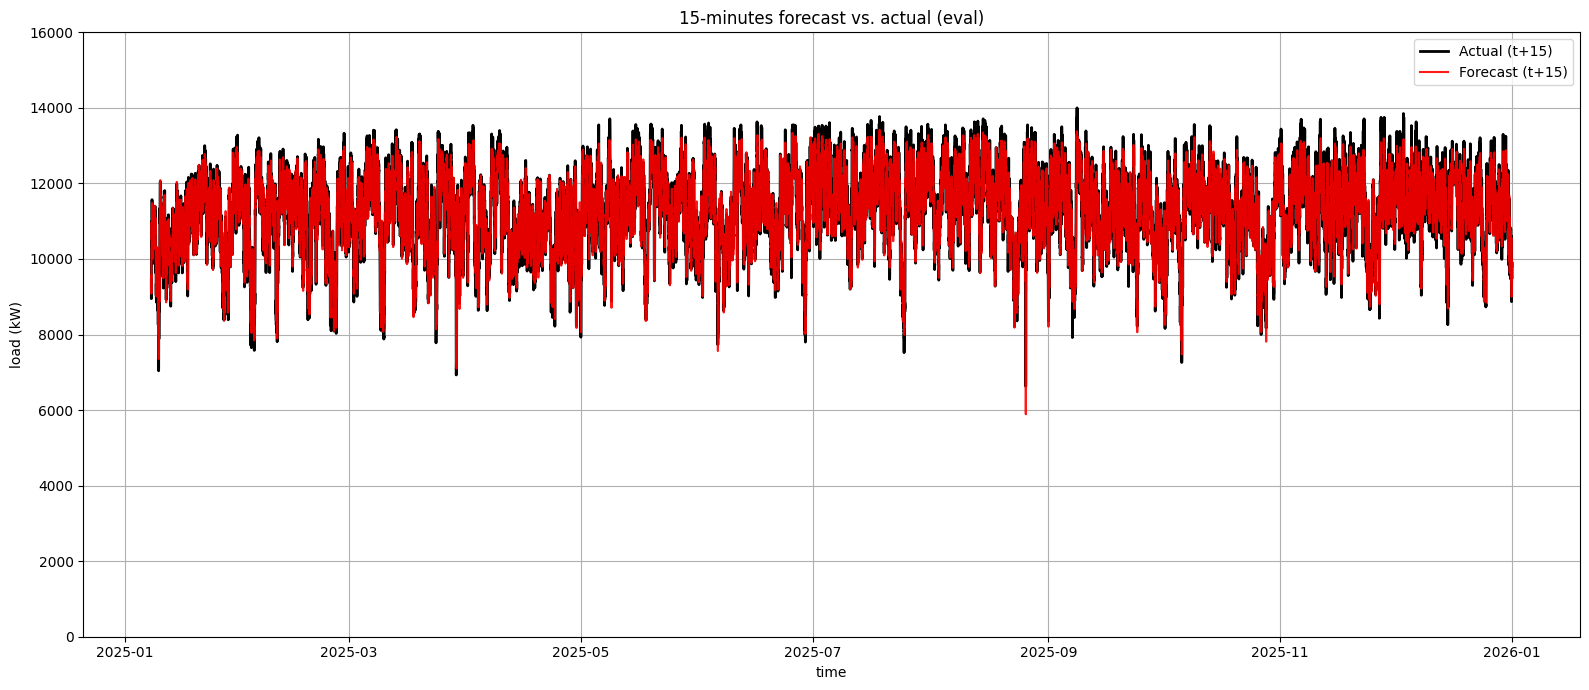

forecast for 2026-03-01 00:00:00 (next 15 minutes): 11,454 kW


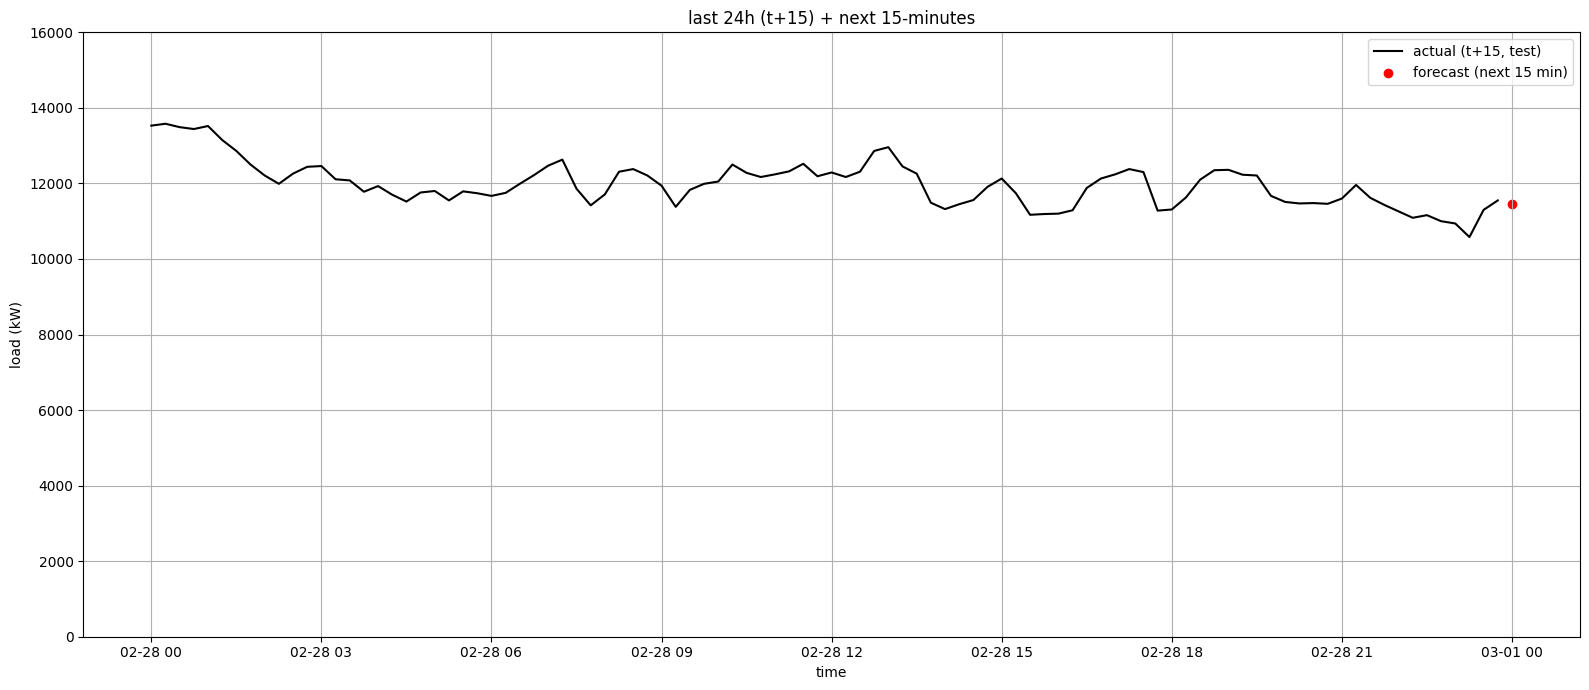

In [102]:
# ===============================
# 1) load datasets
# ===============================
df_train = pd.read_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_train.csv",
                       index_col=0, parse_dates=True)
df_eval  = pd.read_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_eval.csv",
                       index_col=0, parse_dates=True)
df_test  = pd.read_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_test.csv",
                       index_col=0, parse_dates=True)

# Sanity checks (optional)
print(df_train.shape, df_train.index.min(), df_train.index.max())
print(df_eval.shape,  df_eval.index.min(),  df_eval.index.max())
print(df_test.shape,  df_test.index.min(),  df_test.index.max())

# featurelist
keep_columns = [
    "load_15min",
    "load_15min_ago", "load_30min_ago",
    "load_1h_ago", "load_2h_ago", "load_4h_ago", "load_6h_ago",
    "load_12h_ago", "load_24h_ago",
    "rolling_mean_1h", "rolling_mean_4h", "rolling_mean_24h",
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "weekday_sin", "weekday_cos",
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
    # weather
    "temp", "temp_lag1h", "temp_lag3h", "temp_lag24h",
    "rel_humidity",
    "wind",
    "radiation",
    "precip",
]

# ===============================
# 2) helper: build real t+15-target 
#    - X(t): all features for timestamp t
#    - y(t+15): shift target by +15 min 
#    - y-Index set to t+15  → perfect time syncronisation
# ===============================
def make_Xy_15min(df, feature_cols, target_col="load_15min"):
    df = df[feature_cols].copy()
    df["target_15"] = df[target_col].shift(-1)          # t+15
    df = df.dropna(subset=["target_15"])                # delete last row
    y = df["target_15"].copy()
    y.index = y.index + pd.Timedelta("15min")           # Index = forecast time
    X = df.drop(columns=[target_col, "target_15"])
    return X, y

# ===============================
# 3) create X/y for train/eval/test (t+15)
# ===============================
X_train, y_train = make_Xy_15min(df_train, keep_columns)
X_eval,  y_eval  = make_Xy_15min(df_eval,  keep_columns)
X_test,  y_test  = make_Xy_15min(df_test,  keep_columns)

print("Shapes:", X_train.shape, X_eval.shape, X_test.shape)

# change column order for all sets
feature_cols = X_train.columns.tolist()
X_eval = X_eval.reindex(columns=feature_cols)
X_test = X_test.reindex(columns=feature_cols)

# ===============================
# build model (rough tuning)
# ===============================
wrapped_objective_rough = partial(objective_rough_tune,                                                         
                            X_train=X_train, y_train=y_train,
                            X_test=X_eval, y_test=y_eval)   

study_rough = optuna.create_study(direction="minimize")                 # minimize the scorer -> minimize RMSE score
study_rough.optimize(wrapped_objective_rough, n_trials=40)                    # try 40 times to reduce the RMSE score

best_params_rough = study_rough.best_params
best_score_rough = study_rough.best_trial

print("Best params:", best_params_rough)
print("Best RMSE:", best_score_rough)

xgb_rough = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_rough  # <-- set best found parameters automatically
)

xgb_rough.fit(X_train, y_train)

# ===============================
# evaluation of the model (rough tuning) (t+15)
# ===============================
y_train_pred = xgb_rough.predict(X_train)
y_eval_pred  = xgb_rough.predict(X_eval)

print("metric result rough tuning:")
result_rough = metric_results(y_train, y_train_pred, y_eval, y_eval_pred, ndigits=2, target_unit="kW")
display(result_rough)

# ===============================
# build model (fine tuning, 20% range around the best params of rough tuning)
# ===============================
wrapped_objective_fine = partial(objective_fine_tune,                                                     
                            fine_tune_range=0.2,                    # pre-assign the fine_tune_range and other arguments         
                            best_params=best_params_rough,          # of the objective_auto function
                            X_train=X_train, y_train=y_train,
                            X_test=X_eval, y_test=y_eval)    

study_fine = optuna.create_study(direction="minimize")                 # minimize the scorer -> minimize RMSE score
study_fine.optimize(wrapped_objective_fine, n_trials=40)                    # try 40 times to reduce the RMSE score

best_params_fine = study_fine.best_params
best_score_fine = study_fine.best_trial

print("Best params:", best_params_fine)
print("Best RMSE:", best_score_fine)

xgb_fine = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_fine  # <-- set best found parameters automatically
)

xgb_fine.fit(X_train, y_train)

# ===============================
# evaluation of the model (rough tuning) (t+15)
# ===============================
y_train_pred = xgb_fine.predict(X_train)
y_eval_pred  = xgb_fine.predict(X_eval)

print("metric result rough tuning:")
result_fine = metric_results(y_train, y_train_pred, y_eval, y_eval_pred, ndigits=2, target_unit="kW")
display(result_fine)

# ===============================
# create histplot with data used for prediction and the next predicted value
#    y_eval.index == Vorhersagezeitpunkt (t+15)
# ===============================
plt.figure(figsize=(16,7))
plt.plot(y_eval.index, y_eval.values,  label="Actual (t+15)", color="black", linewidth=2)
plt.plot(y_eval.index, y_eval_pred,     label="Forecast (t+15)", color="red", alpha=0.9)
plt.title("15-minutes forecast vs. actual (eval)")
plt.ylim(0, 16000)             # set fix values for axes
plt.xlabel("time"); plt.ylabel("load (kW)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# ===============================
# Inference: NEXT quarter hour from last test time
#    - taking the feature line at the last observed time t
#    - forecast valid for t+15
# ===============================

x_next = df_test[keep_columns].iloc[[-1]].drop(columns=["load_15min"])
# set column order as in training
x_next = x_next.reindex(columns=feature_cols, fill_value=0)

y_next15 = xgb_fine.predict(x_next).item()
t_next   = df_test.index[-1] + pd.Timedelta("15min")
print(f"forecast for {t_next} (next 15 minutes): {y_next15:,.0f} kW")

# visualize: last 24h + t+15 prediction
last_24h = y_test.loc[y_test.index >= (t_next - pd.Timedelta("24h"))]
plt.figure(figsize=(16,7))
plt.plot(last_24h.index, last_24h.values, color="black", label="actual (t+15, test)")
plt.scatter([t_next], [y_next15], color="red", label="forecast (next 15 min)")
plt.title("last 24h (t+15) + next 15-minutes")
plt.ylim(0, 16000)             # set fix values for axes
plt.xlabel("time"); plt.ylabel("load (kW)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()



# 3. - make predictions with future data
- **we need at least 2 days of load data to predict the next 24h**

In [75]:
df_future = load_data_and_weather(path=r"dataset\raw-data\load_data_2026-03-01_2026-03-10_UTC.csv", lat=50.3, lon=6.42, tz="UTC")

📅 - start date: 2026-03-01, end date: 2026-03-10
✅ - Success: There are no missing values in the Data!


,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,load_15min_ago,load_30min_ago,load_1h_ago,load_2h_ago,load_4h_ago,load_6h_ago,load_12h_ago,load_24h_ago,rolling_mean_1h,rolling_mean_4h,rolling_mean_24h,rolling_std_3h,rolling_std_6h,rolling_std_12h,temp_lag1h,temp_lag3h,temp_lag24h,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,holiday,bridging_day
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-03-01 00:00:00,11250,3.000,91.0,11.40,0.0,0.0,75.0,2.11,2026-03-01,10.42,0,12.00,0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11002.5,11188.75,11671.666667,255.431898,327.533326,449.814333,3.0,3.0,3.0,0,0,0,3,2,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.008727,0.999962,1.0,6.123234e-17,6,False,False,False,False,False,False,True,-0.781831,0.62349,1,0,0,1,0,0,0,0,0
2026-03-01 00:15:00,10860,2.875,91.5,10.95,0.0,0.0,57.5,2.03,2026-03-01,10.42,0,12.12,0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11002.5,11188.75,11671.666667,255.431898,327.533326,449.814333,3.0,3.0,3.0,0,15,15,3,2,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.008727,0.999962,1.0,6.123234e-17,6,False,False,False,False,False,False,True,-0.781831,0.62349,1,0,0,1,0,0,0,0,0
2026-03-01 00:30:00,11030,2.750,92.0,10.50,0.0,0.0,40.0,1.95,2026-03-01,10.42,0,12.25,0,10860.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11002.5,11188.75,11671.666667,255.431898,327.533326,449.814333,3.0,3.0,3.0,0,30,30,3,2,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.008727,0.999962,1.0,6.123234e-17,6,False,False,False,False,False,False,True,-0.781831,0.62349,1,0,0,1,0,0,0,0,0
2026-03-01 00:45:00,10870,2.625,92.5,10.05,0.0,0.0,22.5,1.86,2026-03-01,10.42,0,12.38,0,11030.0,10860.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,11002.5,11188.75,11671.666667,255.431898,327.533326,449.814333,3.0,3.0,3.0,0,45,45,3,2,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.008727,0.999962,1.0,6.123234e-17,6,False,False,False,False,False,False,True,-0.781831,0.62349,1,0,0,1,0,0,0,0,0
2026-03-01 01:00:00,10880,2.500,93.0,9.60,0.0,0.0,5.0,1.78,2026-03-01,10.42,0,12.50,0,10870.0,11030.0,11250.0,11250.0,11250.0,11250.0,11250.0,11250.0,10910.0,11188.75,11671.666667,255.431898,327.533326,449.814333,3.0,3.0,3.0,1,0,60,3,2,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.008727,0.999962,1.0,6.123234e-17,6,False,False,False,False,False,False,True,-0.781831,0.62349,1,0,0,1,0,0,0,0,0


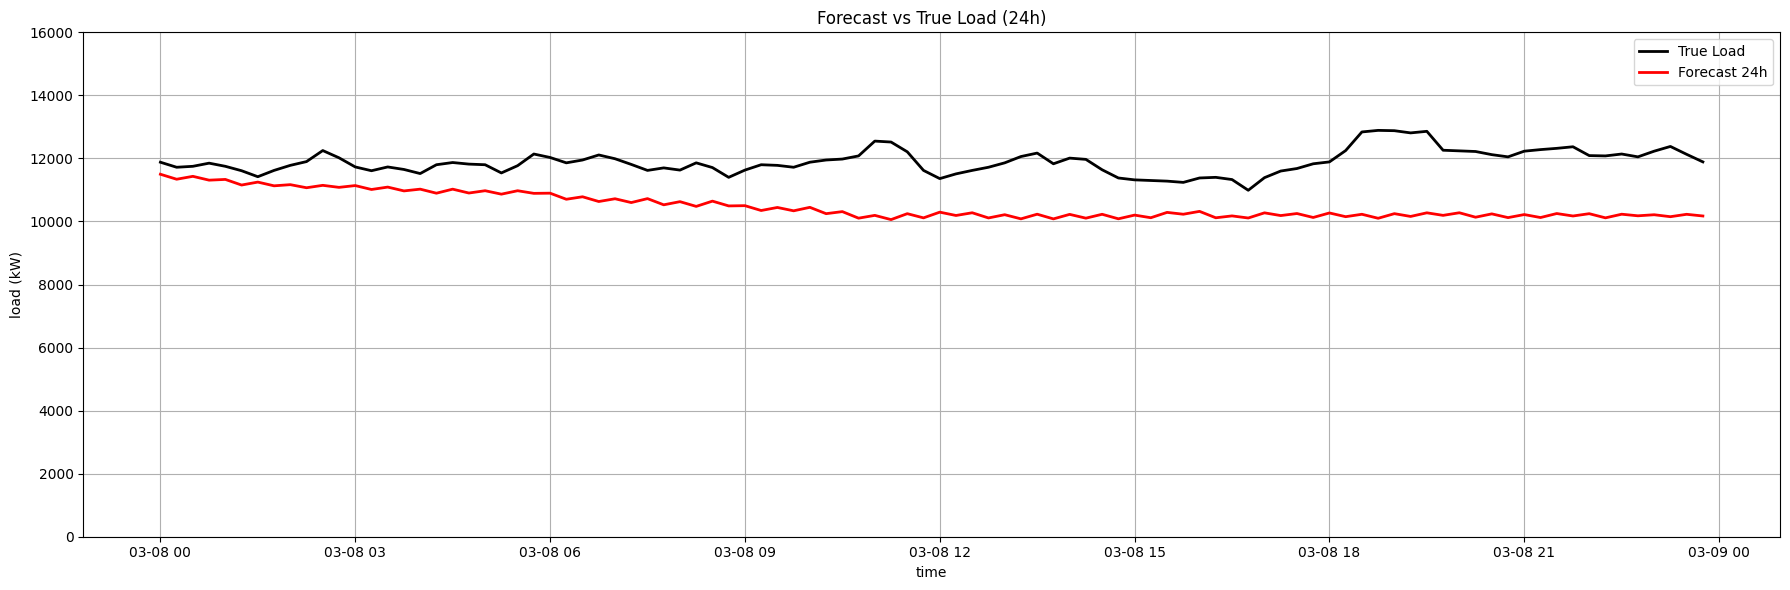

In [78]:

day = 6 # only 0 to 8 will have the True values to compare with -> 9 will be the forecast of a complete unknown day
hour_offset = 0    # max 23
minute_offset = 0  # only 0, 15, 30 or 45

offset = int(hour_offset*4 + minute_offset/15)
forecast_24 = forecast_24h(xgb_fine, df_future.iloc[day*96+offset:(day+1)*96+offset], feature_cols, horizon=96)
y_true = df_future.iloc[(day+1)*96+offset:(day+2)*96+offset]["load_15min"]

plt.figure(figsize=(18,6))

plt.plot(y_true.index, y_true.values,
         label="True Load", color="black", linewidth=2)

plt.plot(forecast_24.index, forecast_24.values,
         label="Forecast 24h", color="red", linewidth=2)

# plt.ylim(0, 16000)                     # feste Last-Achse
plt.title("Forecast vs True Load (24h)")
plt.ylim(0, 16000)             # set fix values for axes
plt.xlabel("time")
plt.ylabel("load (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


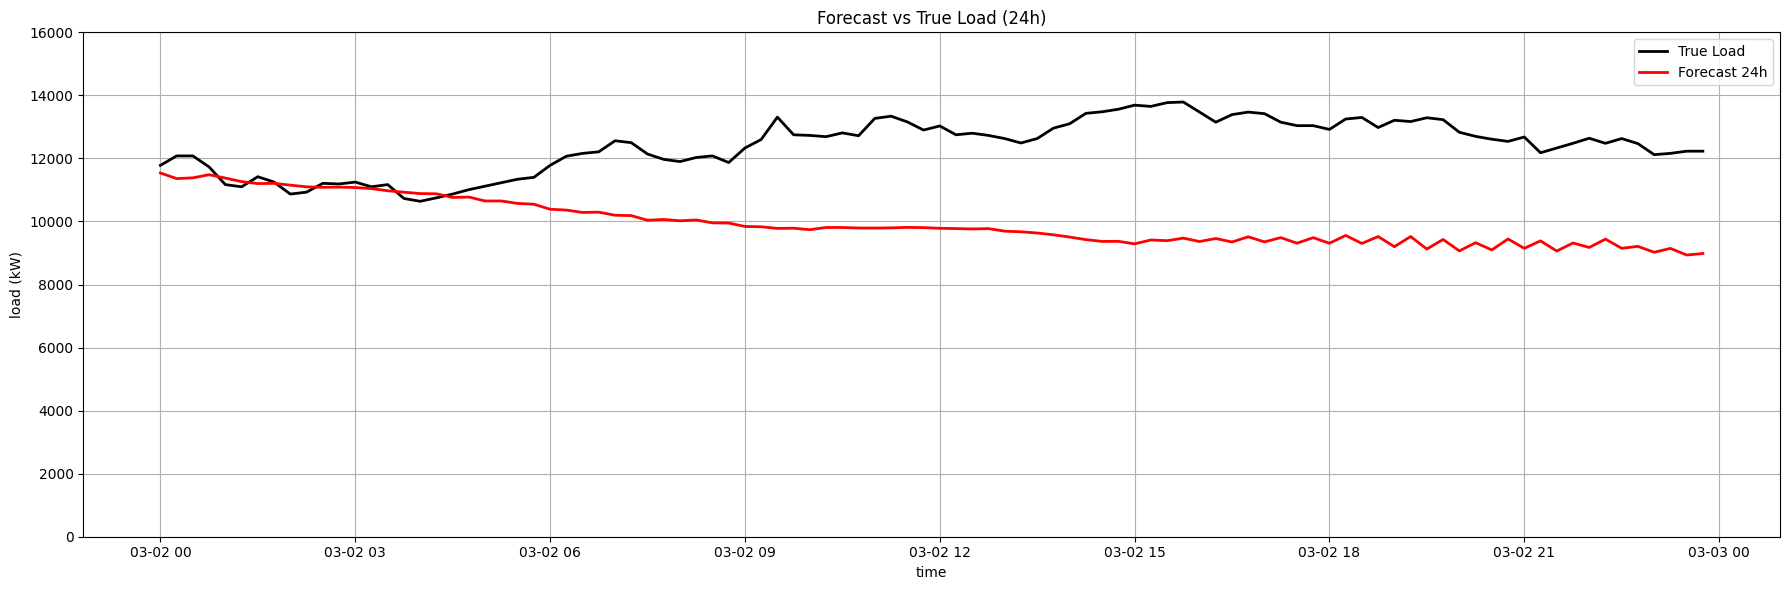

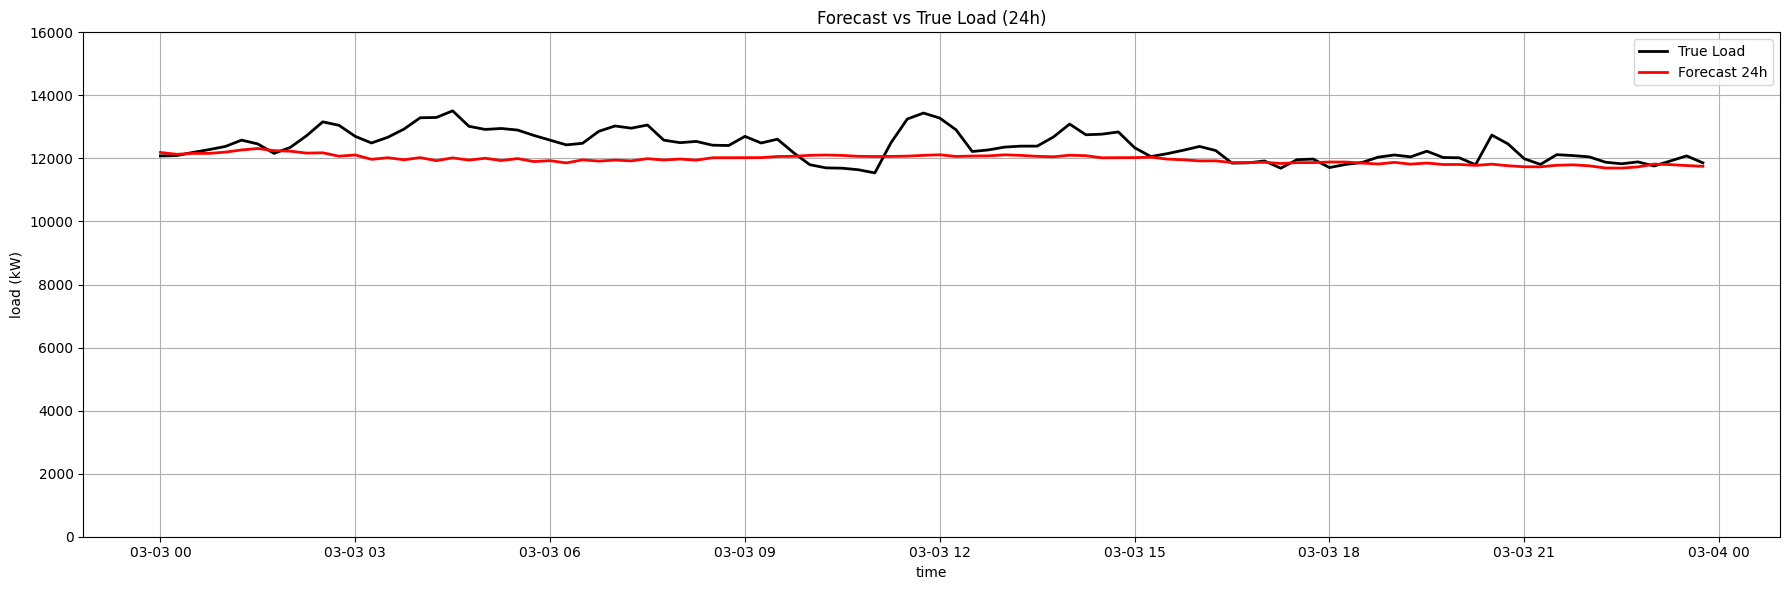

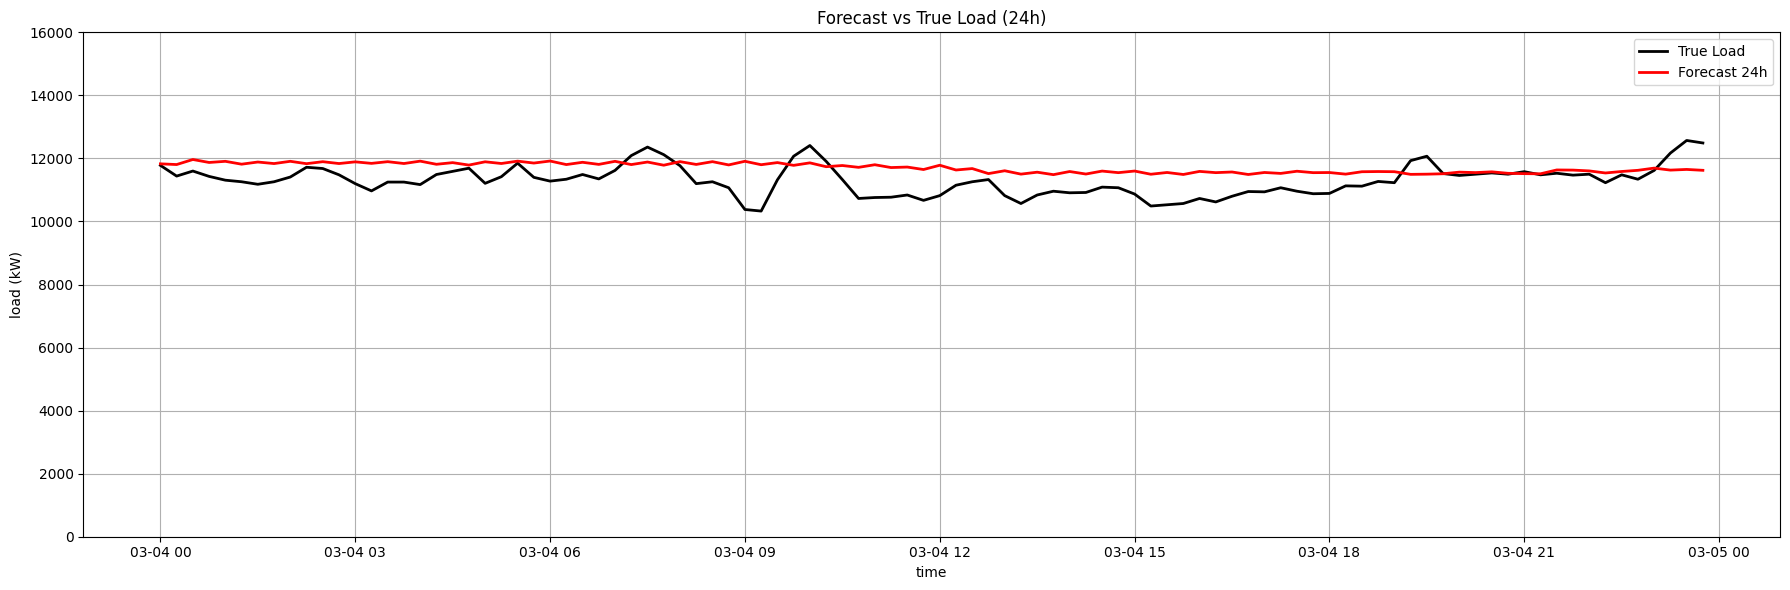

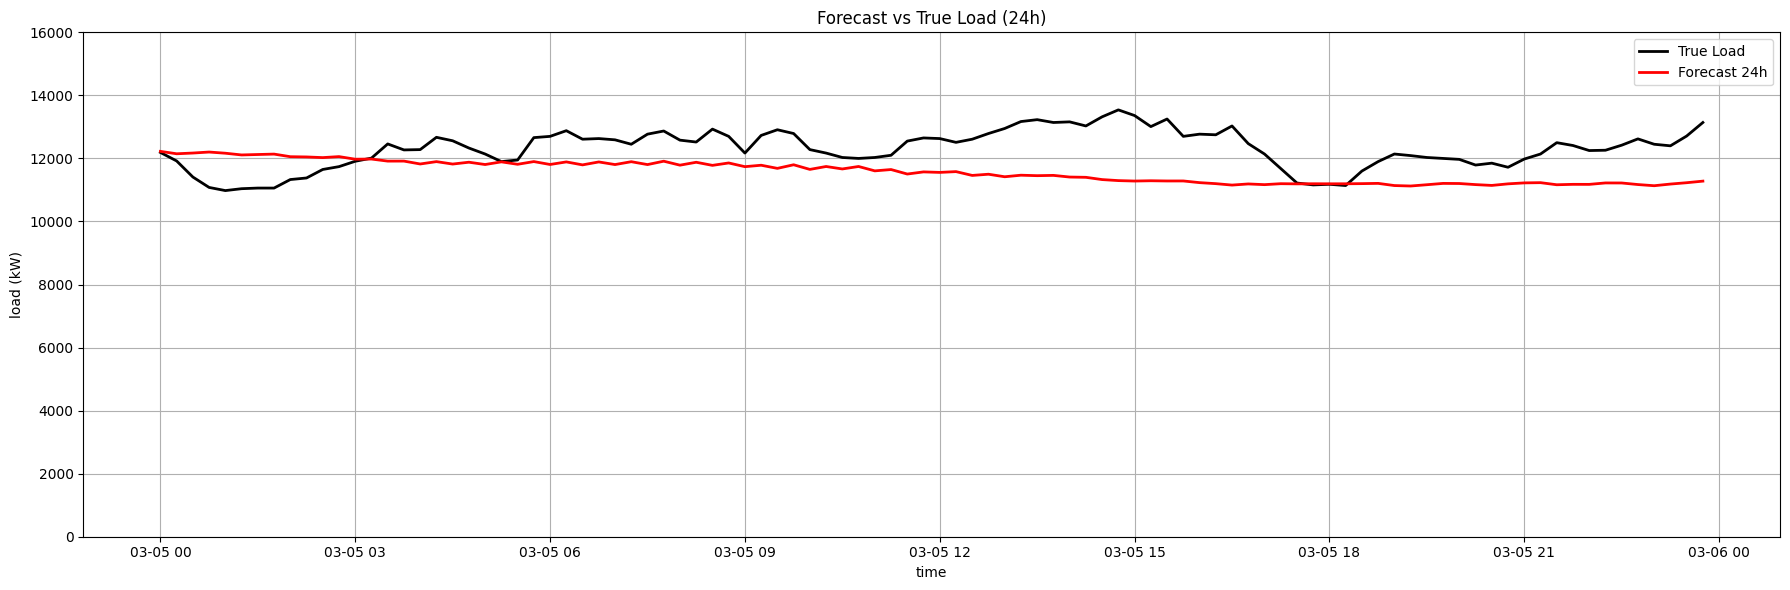

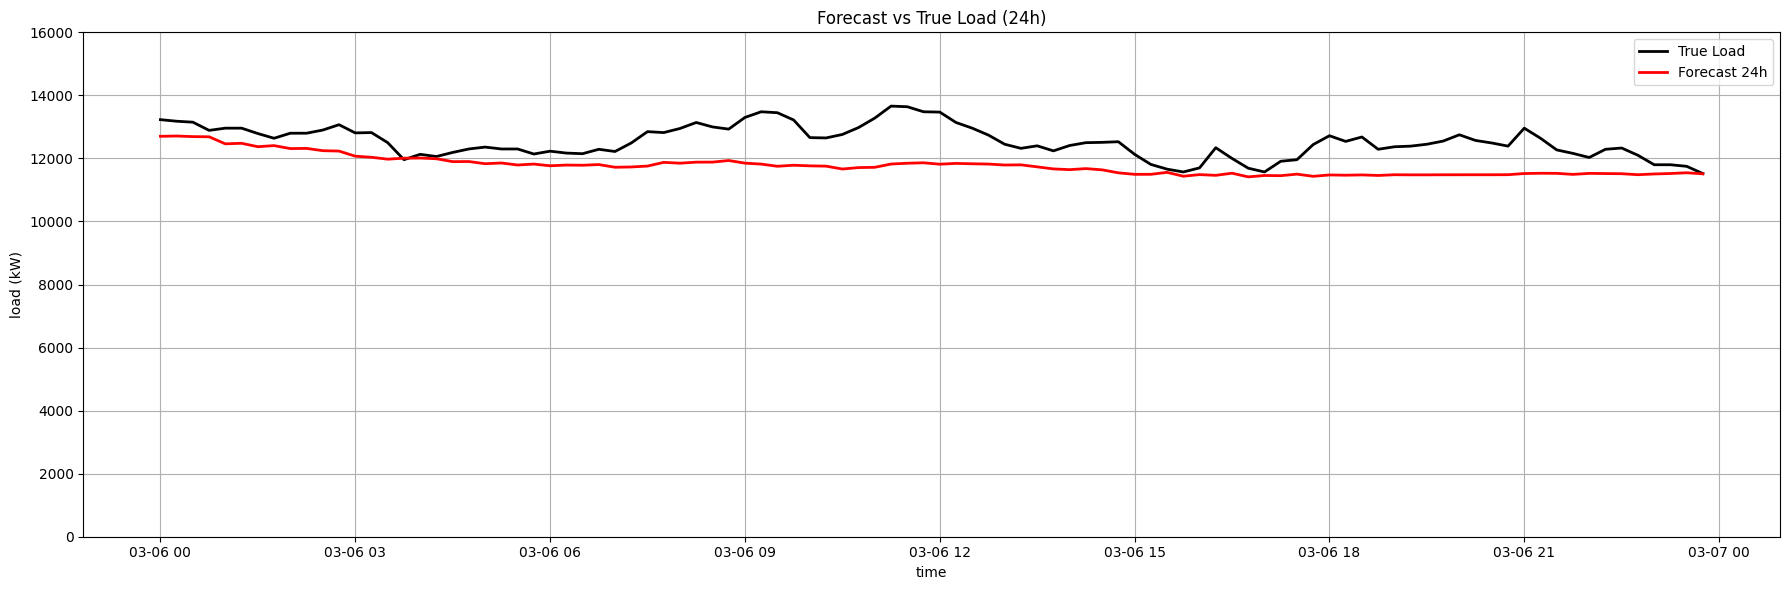

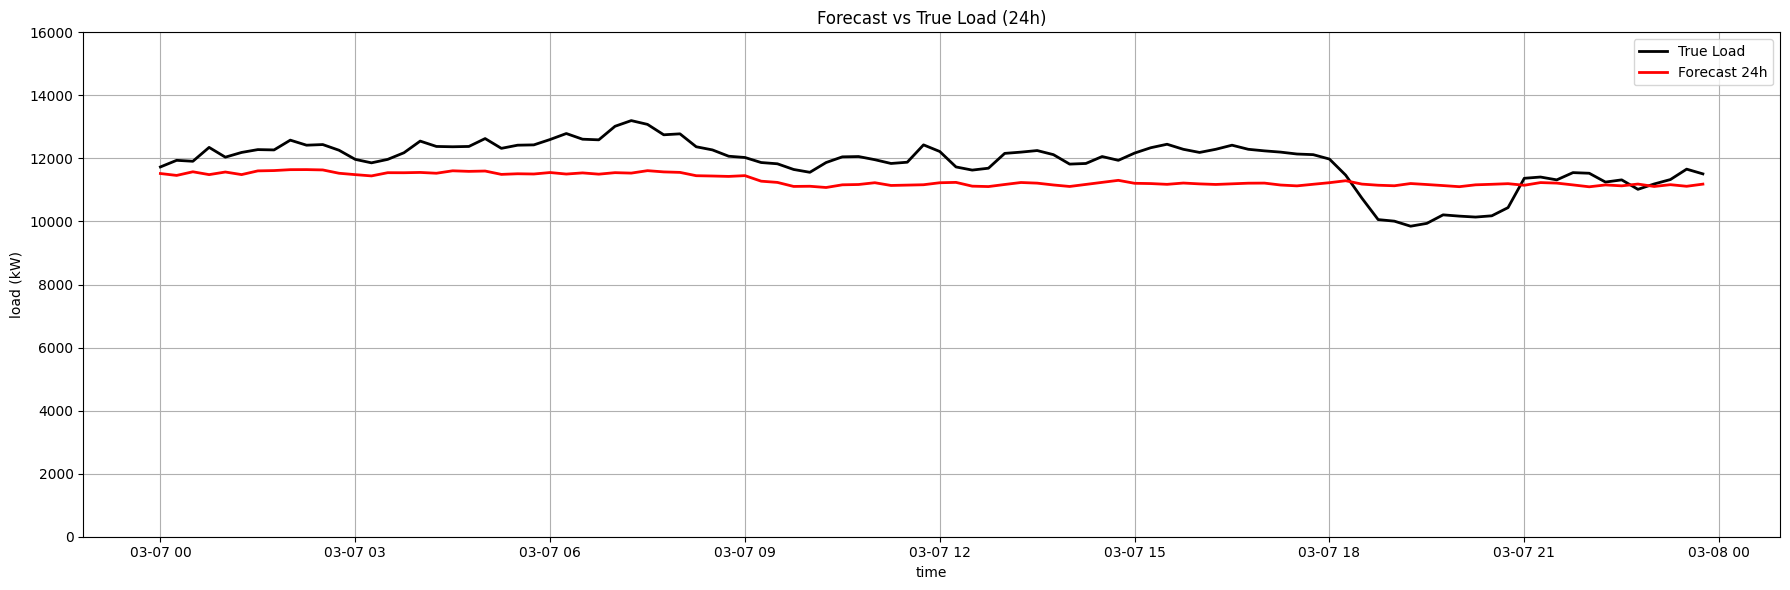

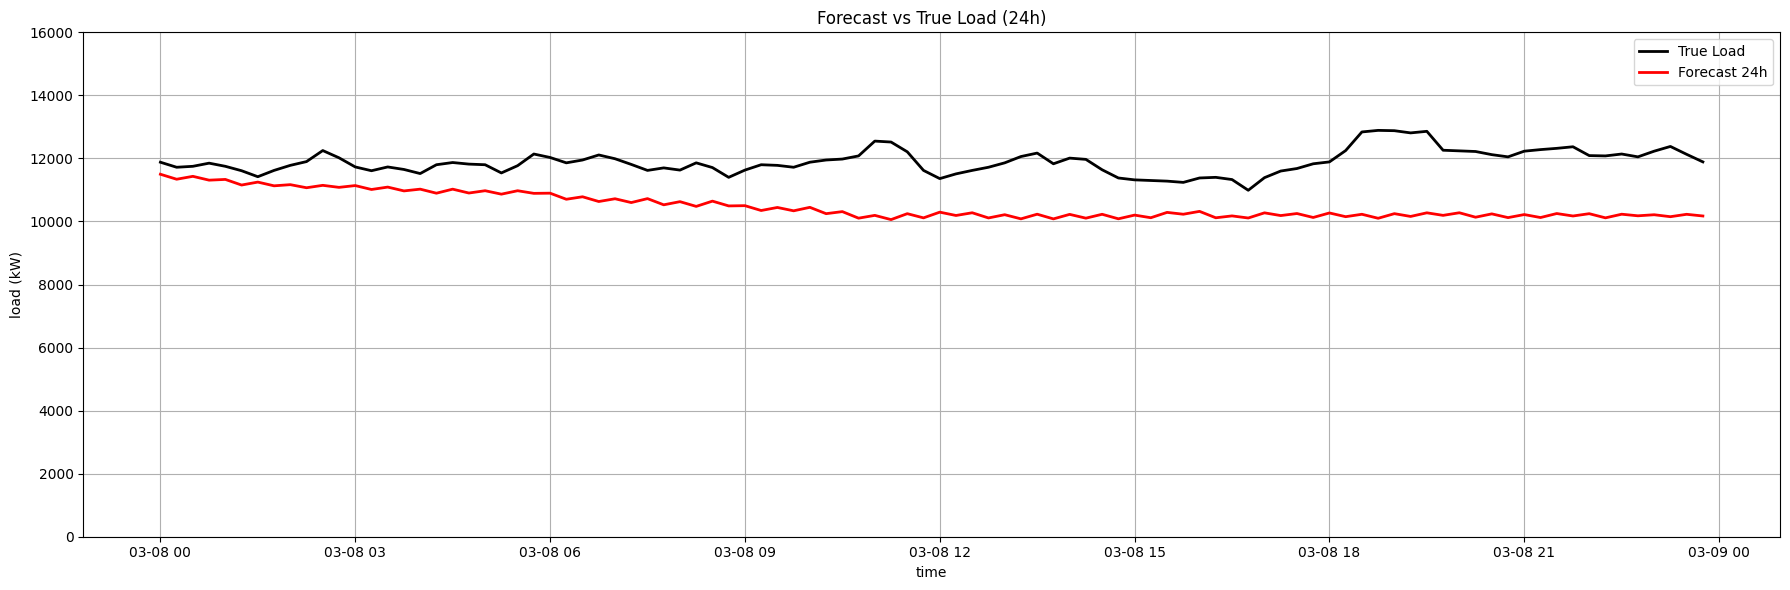

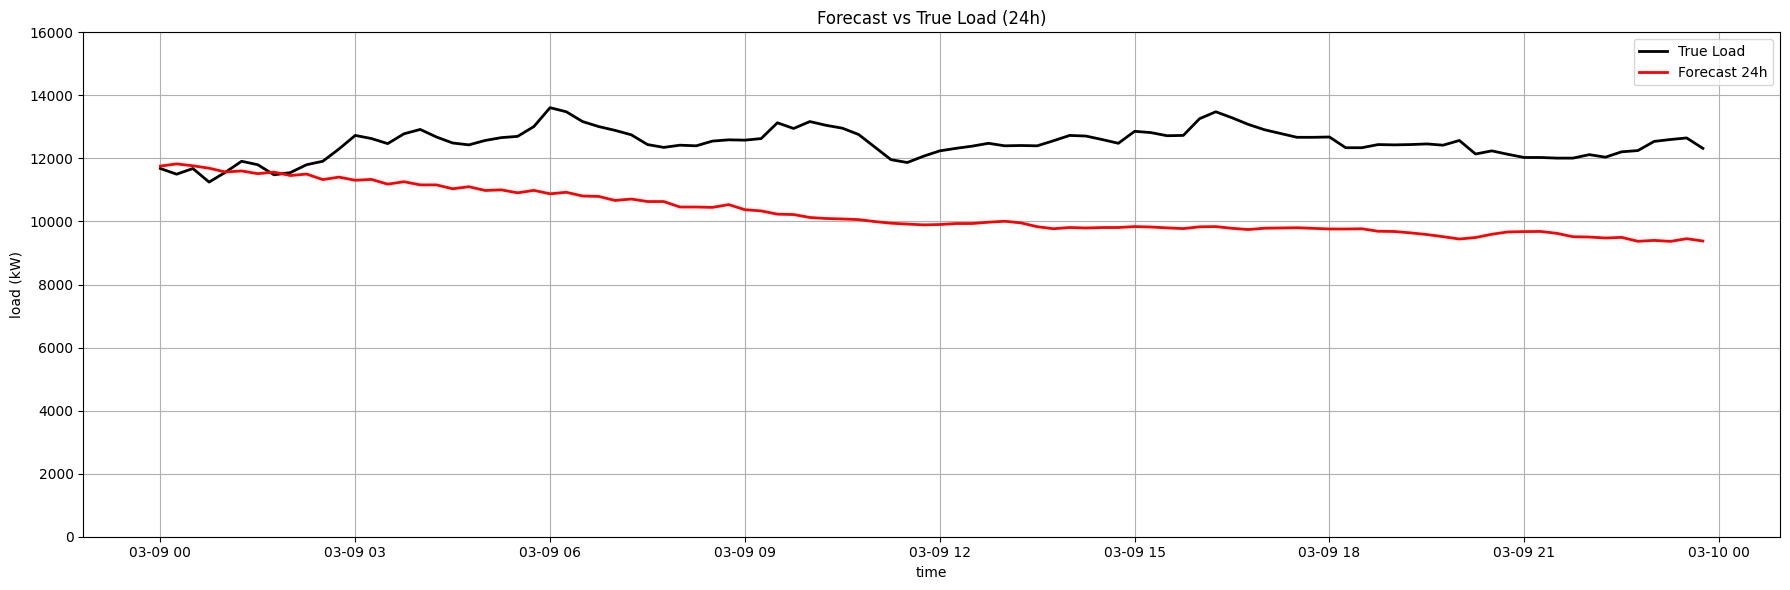

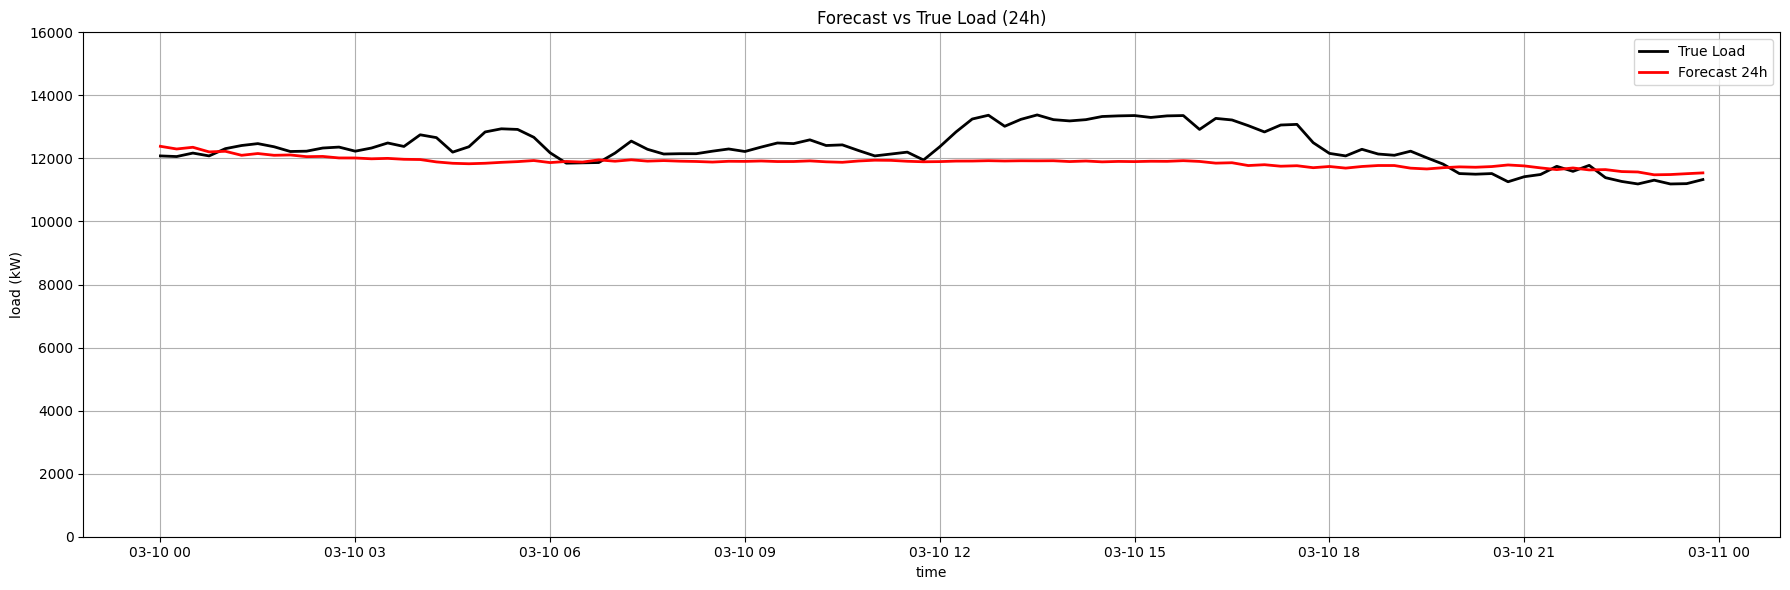

In [77]:
for day in range(0,9):
    # day = 5 # only 0 to 8 will have the True values to compare with -> 9 will be the forecast of a complete unknown day
    hour_offset = 0    # max 23
    minute_offset = 0  # only 0, 15, 30 or 45

    offset = int(hour_offset*4 + minute_offset/15)
    forecast_24 = forecast_24h(xgb_fine, df_future.iloc[day*96+offset:(day+1)*96+offset], feature_cols, horizon=96)
    y_true = df_future.iloc[(day+1)*96+offset:(day+2)*96+offset]["load_15min"]

    plt.figure(figsize=(18,6))

    plt.plot(y_true.index, y_true.values,
            label="True Load", color="black", linewidth=2)

    plt.plot(forecast_24.index, forecast_24.values,
            label="Forecast 24h", color="red", linewidth=2)

    # plt.ylim(0, 16000)                     # feste Last-Achse
    plt.title("Forecast vs True Load (24h)")
    plt.ylim(0, 16000)             # set fix values for axes
    plt.xlabel("time")
    plt.ylabel("load (kW)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. - train model without weather data

In [ ]:
# ============================================
# create X/y for train/eval/test  (NO WEATHER)
# ============================================
X_train_nw, y_train_nw = make_Xy_15min(df_train, keep_columns_no_weather)
X_eval_nw,  y_eval_nw  = make_Xy_15min(df_eval,  keep_columns_no_weather)
X_test_nw,  y_test_nw  = make_Xy_15min(df_test,  keep_columns_no_weather)

# reorder columns
feature_cols_nw = X_train_nw.columns.tolist()
X_eval_nw = X_eval_nw.reindex(columns=feature_cols_nw)
X_test_nw = X_test_nw.reindex(columns=feature_cols_nw)

wrapped_objective_rough_nw = partial(
    objective_rough_tune,
    X_train=X_train_nw, y_train=y_train_nw,
    X_test=X_eval_nw,   y_test=y_eval_nw
)

study_rough_nw = optuna.create_study(direction="minimize")
study_rough_nw.optimize(wrapped_objective_rough_nw, n_trials=40)

best_params_rough_nw = study_rough_nw.best_params

xgb_rough_nw = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_rough_nw
)
xgb_rough_nw.fit(X_train_nw, y_train_nw)

wrapped_objective_fine_nw = partial(
    objective_fine_tune,
    fine_tune_range=0.2,
    best_params=best_params_rough_nw,
    X_train=X_train_nw, y_train=y_train_nw,
    X_test=X_eval_nw,   y_test=y_eval_nw
)

study_fine_nw = optuna.create_study(direction="minimize")
study_fine_nw.optimize(wrapped_objective_fine_nw, n_trials=40)

best_params_fine_nw = study_fine_nw.best_params

xgb_fine_nw = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_fine_nw
)

xgb_fine_nw.fit(X_train_nw, y_train_nw)


# metrics WITH weather
y_train_pred = xgb_fine.predict(X_train)
y_eval_pred  = xgb_fine.predict(X_eval)
result_with_weather = metric_results(
    y_train, y_train_pred, y_eval, y_eval_pred, target_unit="kW"
)

# metrics WITHOUT weather
y_train_pred_nw = xgb_fine_nw.predict(X_train_nw)
y_eval_pred_nw  = xgb_fine_nw.predict(X_eval_nw)
result_no_weather = metric_results(
    y_train_nw, y_train_pred_nw, y_eval_nw, y_eval_pred_nw, target_unit="kW"
)

print("===== MODEL WITH WEATHER =====")
display(result_with_weather)

print("===== MODEL WITHOUT WEATHER =====")
display(result_no_weather)


[I 2026-03-12 10:30:13,138] A new study created in memory with name: no-name-7b941429-48eb-4b15-b8b8-a788de05d585
[I 2026-03-12 10:30:15,045] Trial 0 finished with value: 317.20211453695265 and parameters: {'n_estimators': 1177, 'max_depth': 7, 'learning_rate': 0.07836214899028353, 'subsample': 0.9698255988435649, 'colsample_bytree': 0.7521041150537108, 'min_child_weight': 4, 'gamma': 0.4882565037542147, 'reg_alpha': 0.13767526889458653, 'reg_lambda': 5.383766906016043}. Best is trial 0 with value: 317.20211453695265.
[I 2026-03-12 10:30:15,982] Trial 1 finished with value: 329.57242380868036 and parameters: {'n_estimators': 842, 'max_depth': 5, 'learning_rate': 0.017590458606114776, 'subsample': 0.6791769654960578, 'colsample_bytree': 0.7286115465009025, 'min_child_weight': 5, 'gamma': 3.5196504704308627, 'reg_alpha': 0.2741028026763387, 'reg_lambda': 6.484121577397463}. Best is trial 0 with value: 317.20211453695265.
[I 2026-03-12 10:30:17,939] Trial 2 finished with value: 315.269944

===== MODEL WITH WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.54,233.35,180.43,2.09,1.61
test,91.12,310.28,240.25,2.75,2.13
diff,5.41,-76.92,-59.82,-0.66,-0.52


===== MODEL WITHOUT WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.53,233.45,180.7,2.09,1.62
test,91.18,309.24,239.02,2.74,2.12
diff,5.35,-75.79,-58.32,-0.65,-0.5


# 5. - train model with more weather data

In [ ]:
# ============================================
# create X/y for train/eval/test  (MORE WEATHER)
# ============================================
X_train_mw, y_train_mw = make_Xy_15min(df_train, keep_columns_no_weather)
X_eval_mw,  y_eval_mw  = make_Xy_15min(df_eval,  keep_columns_no_weather)
X_test_mw,  y_test_mw  = make_Xy_15min(df_test,  keep_columns_no_weather)

# reorder columns
feature_cols_mw = X_train_mw.columns.tolist()
X_eval_mw = X_eval_mw.reindex(columns=feature_cols_mw)
X_test_mw = X_test_mw.reindex(columns=feature_cols_mw)

wrapped_objective_rough_mw = partial(
    objective_rough_tune,
    X_train=X_train_mw, y_train=y_train_mw,
    X_test=X_eval_mw,   y_test=y_eval_mw
)

study_rough_mw = optuna.create_study(direction="minimize")
study_rough_mw.optimize(wrapped_objective_rough_mw, n_trials=40)

best_params_rough_mw = study_rough_mw.best_params

xgb_rough_mw = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_rough_mw
)
xgb_rough_mw.fit(X_train_mw, y_train_mw)

wrapped_objective_fine_mw = partial(
    objective_fine_tune,
    fine_tune_range=0.2,
    best_params=best_params_rough_mw,
    X_train=X_train_mw, y_train=y_train_mw,
    X_test=X_eval_mw,   y_test=y_eval_mw
)

study_fine_mw = optuna.create_study(direction="minimize")
study_fine_mw.optimize(wrapped_objective_fine_mw, n_trials=40)

best_params_fine_mw = study_fine_mw.best_params

xgb_fine_mw = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_fine_mw
)

xgb_fine_mw.fit(X_train_mw, y_train_mw)


# metrics WITH weather
y_train_pred = xgb_fine.predict(X_train)
y_eval_pred  = xgb_fine.predict(X_eval)
result_with_weather = metric_results(
    y_train, y_train_pred, y_eval, y_eval_pred, target_unit="kW"
)

# metrics WITHOUT weather
y_train_pred_mw = xgb_fine_mw.predict(X_train_mw)
y_eval_pred_mw  = xgb_fine_mw.predict(X_eval_mw)
result_more_weather = metric_results(
    y_train_mw, y_train_pred_mw, y_eval_mw, y_eval_pred_mw, target_unit="kW"
)

print("===== MODEL WITH WEATHER =====")
display(result_with_weather)

print("===== MODEL WITHOUT WEATHER =====")
display(result_no_weather)

print("===== MODEL WITH MORE WEATHER =====")
display(result_more_weather)


[I 2026-03-12 10:37:13,377] A new study created in memory with name: no-name-b4db97eb-cf75-4afa-a971-415ed89d826b
[I 2026-03-12 10:37:14,164] Trial 0 finished with value: 330.08997049379985 and parameters: {'n_estimators': 709, 'max_depth': 5, 'learning_rate': 0.01402825835538777, 'subsample': 0.7754755255400338, 'colsample_bytree': 0.8868025658976164, 'min_child_weight': 3, 'gamma': 1.3646740430368487, 'reg_alpha': 0.31564277612307545, 'reg_lambda': 4.261960066943258}. Best is trial 0 with value: 330.08997049379985.
[I 2026-03-12 10:37:15,845] Trial 1 finished with value: 313.2232828530165 and parameters: {'n_estimators': 791, 'max_depth': 8, 'learning_rate': 0.027868492296509548, 'subsample': 0.5465451806595585, 'colsample_bytree': 0.8197147005671539, 'min_child_weight': 1, 'gamma': 2.2071683871284424, 'reg_alpha': 0.14110144467544955, 'reg_lambda': 3.862305874745758}. Best is trial 1 with value: 313.2232828530165.
[I 2026-03-12 10:37:16,523] Trial 2 finished with value: 315.05145910

===== MODEL WITH WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.54,233.35,180.43,2.09,1.61
test,91.12,310.28,240.25,2.75,2.13
diff,5.41,-76.92,-59.82,-0.66,-0.52


===== MODEL WITHOUT WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.53,233.45,180.7,2.09,1.62
test,91.18,309.24,239.02,2.74,2.12
diff,5.35,-75.79,-58.32,-0.65,-0.5


===== MODEL WITH MORE WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.43,237.05,183.37,2.12,1.64
test,91.23,308.34,238.35,2.73,2.11
diff,5.19,-71.3,-54.98,-0.61,-0.47


# 6. - train model with testing perfect features

In [107]:
# ============================================
# create X/y for train/eval/test  (MORE WEATHER)
# ============================================
X_train_test, y_train_test = make_Xy_15min(df_train, keep_columns_test)
X_eval_test,  y_eval_test  = make_Xy_15min(df_eval,  keep_columns_test)
X_test_test,  y_test_test  = make_Xy_15min(df_test,  keep_columns_test)

# reorder columns
feature_cols_test = X_train_test.columns.tolist()
X_eval_test = X_eval_test.reindex(columns=feature_cols_test)
X_test_test = X_test_test.reindex(columns=feature_cols_test)

wrapped_objective_rough_test = partial(
    objective_rough_tune,
    X_train=X_train_test, y_train=y_train_test,
    X_test=X_eval_test,   y_test=y_eval_test
)

study_rough_test = optuna.create_study(direction="minimize")
study_rough_test.optimize(wrapped_objective_rough_test, n_trials=80)

best_params_rough_test = study_rough_test.best_params

xgb_rough_test = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_rough_test
)
xgb_rough_test.fit(X_train_test, y_train_test)

wrapped_objective_fine_test = partial(
    objective_fine_tune,
    fine_tune_range=0.2,
    best_params=best_params_rough_test,
    X_train=X_train_test, y_train=y_train_test,
    X_test=X_eval_test,   y_test=y_eval_test
)

study_fine_test = optuna.create_study(direction="minimize")
study_fine_test.optimize(wrapped_objective_fine_test, n_trials=40)

best_params_fine_test = study_fine_test.best_params

xgb_fine_test = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_fine_test
)

xgb_fine_test.fit(X_train_test, y_train_test)


# metrics WITH weather
y_train_pred = xgb_fine.predict(X_train)
y_eval_pred  = xgb_fine.predict(X_eval)
result_with_weather = metric_results(
    y_train, y_train_pred, y_eval, y_eval_pred, target_unit="kW"
)

# metrics WITHOUT weather
y_train_pred_test = xgb_fine_test.predict(X_train_test)
y_eval_pred_test  = xgb_fine_test.predict(X_eval_test)
result_test_weather = metric_results(
    y_train_test, y_train_pred_test, y_eval_test, y_eval_pred_test, target_unit="kW"
)

print("===== MODEL WITH WEATHER =====")
display(result_with_weather)

print("===== MODEL WITH MORE WEATHER =====")
display(result_more_weather)

print("===== MODEL TEST WEATHER =====")
display(result_test_weather)


[I 2026-03-12 12:33:55,267] A new study created in memory with name: no-name-2dea443e-2360-4470-a8fb-5b683e43238c
[I 2026-03-12 12:33:55,733] Trial 0 finished with value: 3806.53951226398 and parameters: {'n_estimators': 471, 'max_depth': 5, 'learning_rate': 0.0024162545735393467, 'subsample': 0.23818602581379292, 'colsample_bytree': 0.2645517256380968, 'min_child_weight': 10, 'gamma': 4.285659525294228, 'reg_alpha': 0.692042333045479, 'reg_lambda': 2.4531977410743013}. Best is trial 0 with value: 3806.53951226398.
[I 2026-03-12 12:33:56,215] Trial 1 finished with value: 1002.2220702064965 and parameters: {'n_estimators': 461, 'max_depth': 5, 'learning_rate': 0.008736156830008546, 'subsample': 0.3000072123062568, 'colsample_bytree': 0.3076502626290992, 'min_child_weight': 2, 'gamma': 4.4080393578448005, 'reg_alpha': 0.3055975728443085, 'reg_lambda': 7.421073490622789}. Best is trial 1 with value: 1002.2220702064965.
[I 2026-03-12 12:34:00,994] Trial 2 finished with value: 1259.64303212

===== MODEL WITH WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.29,241.5,186.54,2.16,1.67
test,91.12,310.27,240.17,2.75,2.13
diff,5.17,-68.77,-53.63,-0.59,-0.46


===== MODEL WITH MORE WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.43,237.05,183.37,2.12,1.64
test,91.23,308.34,238.35,2.73,2.11
diff,5.19,-71.3,-54.98,-0.61,-0.47


===== MODEL TEST WEATHER =====


,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,16.43,1146.21,885.6,10.25,7.92
test,17.13,947.98,756.91,8.41,6.71
diff,-0.7,198.23,128.7,1.84,1.21
